In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

In [7]:
X, y = make_blobs(n_features=2, n_samples=30, centers=2, random_state=5, cluster_std=0.4)

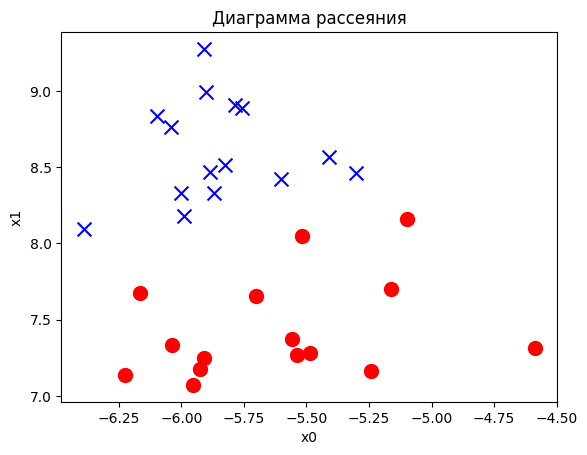

In [8]:
plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния")
plt.xlabel('x0')
plt.ylabel('x1')
plt.show()

In [11]:
svm_linear = SVC(kernel='linear', C=100)
svm_linear.fit(X, y)

,C,100
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [12]:
svm_linear.coef_

array([[-2.49920793,  6.14683189]])

In [13]:
svm_linear.intercept_

array([-64.2533988])

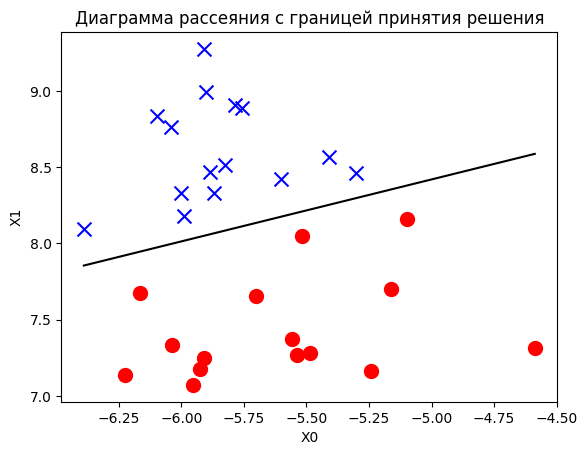

In [14]:
X0 = np.linspace(X[:, 0].min(),X[:, 0].max(), X.shape[0])

plt.plot(X0,-svm_linear.intercept_[0]/svm_linear.coef_[0][1]-svm_linear.coef_[0][0]/svm_linear.coef_[0][1]*X0, c='k')

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния c границей принятия решения")
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()

In [15]:
svm_linear.support_vectors_

array([[-5.51629264,  8.04763857],
       [-5.30025769,  8.46071981],
       [-5.9879581 ,  8.18112559]])

In [16]:
svm_linear.support_

array([ 0,  8, 29], dtype=int32)

In [17]:
svm_linear.n_support_

array([1, 2], dtype=int32)

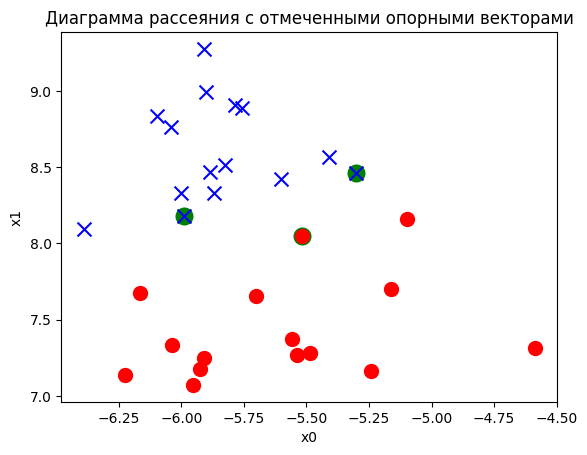

In [18]:
plt.scatter(svm_linear.support_vectors_[:, 0],svm_linear.support_vectors_[:, 1], linewidth=7, facecolors='green')

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния c отмеченными опорными векторами")
plt.xlabel('x0')
plt.ylabel('x1')
plt.show()

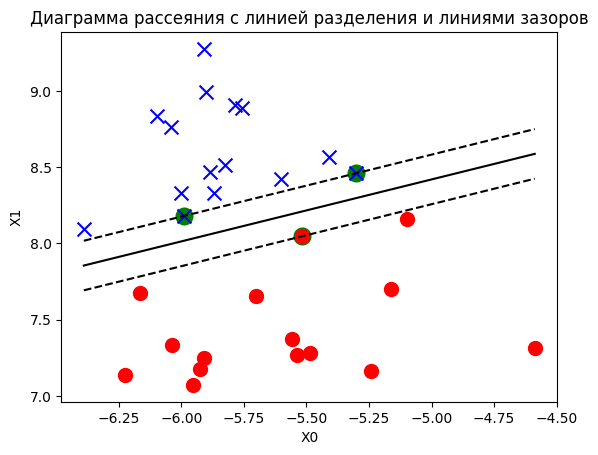

In [19]:
plt.plot(X0,-svm_linear.intercept_[0]/svm_linear.coef_[0][1]-svm_linear.coef_[0][0]/svm_linear.coef_[0][1]*X0, c='k')

plt.plot(X0,(-svm_linear.intercept_[0]-1)/svm_linear.coef_[0][1]-svm_linear.coef_[0][0]/svm_linear.coef_[0][1]*X0,linestyle='--', c='k')
plt.plot(X0,(-svm_linear.intercept_[0]+1)/svm_linear.coef_[0][1]-svm_linear.coef_[0][0]/svm_linear.coef_[0][1]*X0,linestyle='--', c='k')

plt.scatter(svm_linear.support_vectors_[:, 0],svm_linear.support_vectors_[:, 1], linewidth=7, facecolors='green')

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния c линией разделения и линиями зазоров")
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()

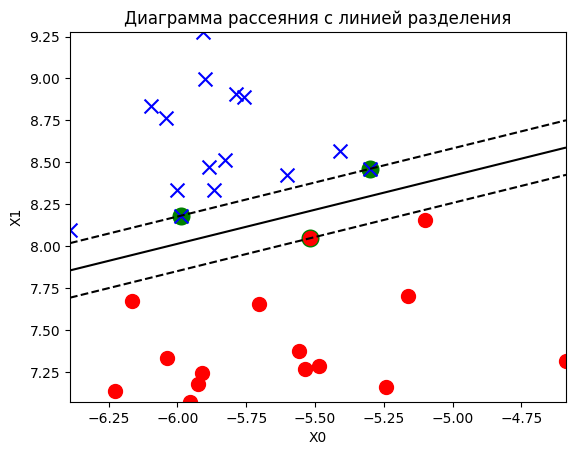

In [20]:
X0 = np.linspace(X[:, 0].min(), X[:, 0].max(), X.shape[0])
X1 = np.linspace(X[:, 1].min(), X[:, 1].max(), X.shape[0])

X0_grid, X1_grid = np.meshgrid(X0, X1)
Z = svm_linear.intercept_[0] + svm_linear.coef_[0][0] * X0_grid +  svm_linear.coef_[0][1] * X1_grid
plt.contour(X0_grid, X1_grid, Z, colors='k', levels=[-1, 0, 1], linestyles=['--', '-', '--'])

plt.scatter(svm_linear.support_vectors_[:, 0],svm_linear.support_vectors_[:, 1], linewidth=7, facecolors='green')

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния c линией разделения")
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()

In [21]:
def plot_decision_regions(X, y, model):
    plt.scatter(model.support_vectors_[:, 0],model.support_vectors_[:, 1], linewidth=7, facecolors='green')

    plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
    plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

    X0 = np.linspace(X[:, 0].min(),X[:, 0].max(), X.shape[0])
    X1 = np.linspace(X[:, 1].min(),X[:, 1].max(), X.shape[0])

    X0_grid, X1_grid = np.meshgrid(X0, X1)
    Z = model.decision_function(np.array([X0_grid.ravel(), X1_grid.ravel()]).T).reshape(X0_grid.shape)
    plt.contour(X0_grid, X1_grid, Z, colors='k', levels=[-1, 0, 1], linestyles=['--', '-', '--'])
    plt.contourf(X0_grid, X1_grid, Z, colors='k', levels=[-1, 0, 1], alpha=0.5)

    plt.title("Диаграмма рассеяния c линией разделения и зазором")
    plt.xlabel('X0')
    plt.ylabel('X1')
    plt.show()

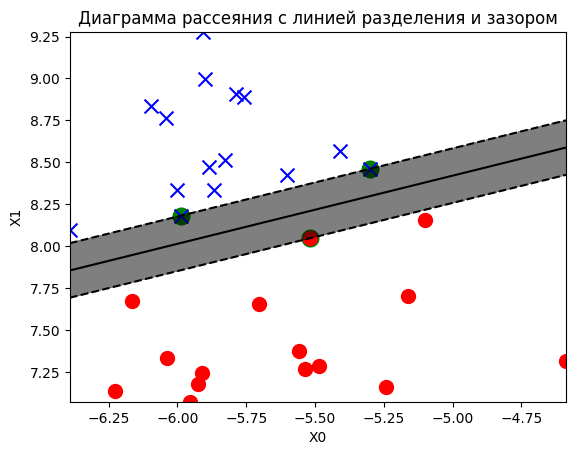

In [23]:
plot_decision_regions(X, y, svm_linear)

In [24]:
y_pred =  svm_linear.predict(X)

In [31]:
accuracy_score(y, y_pred)

1.0

In [33]:
confusion_matrix(y, y_pred)

array([[15,  0],
       [ 0, 15]])

In [34]:
observation_new = [[-5.25, 7.5]]

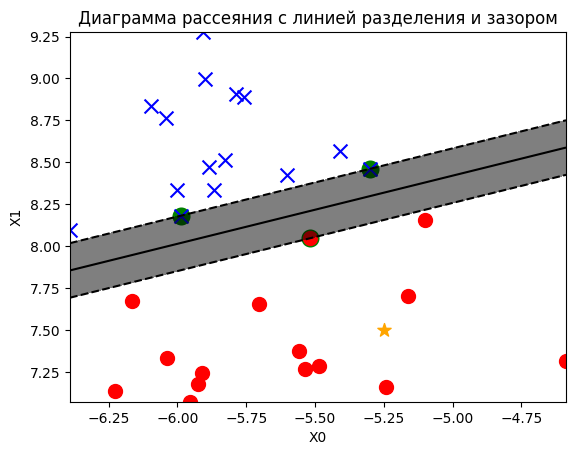

In [35]:
plt.scatter(observation_new[0][0], observation_new[0][1], marker='*', s=100, color='orange')
plot_decision_regions(X, y, svm_linear)

In [36]:
svm_linear.decision_function(observation_new)

array([-5.03131797])

In [37]:
svm_linear.predict(observation_new)

array([0])

In [39]:
from sklearn.datasets import make_circles

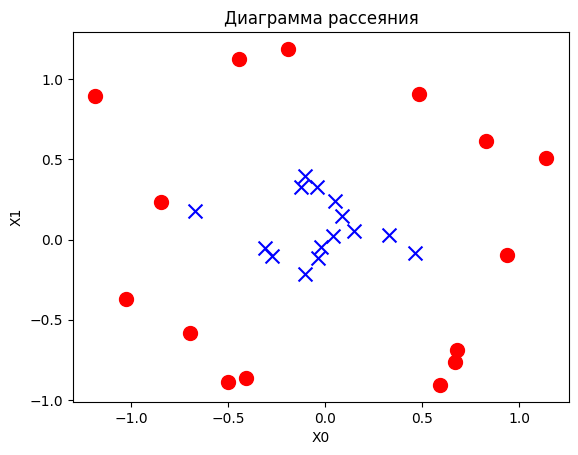

In [40]:
X, y = make_circles(n_samples=30, random_state=5, factor=.1, noise=.2)

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния")
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()

In [41]:
svm_rbf = SVC(kernel='rbf', C=100).fit(X, y)

In [42]:
svm_rbf.n_support_
svm_rbf.support_
svm_rbf.support_vectors_

array([[ 0.9388294 , -0.09554628],
       [-0.84682371,  0.23287306],
       [-0.19166925,  1.18895776],
       [-0.69539045, -0.58523359],
       [ 0.68060508, -0.68615145],
       [ 0.48354792,  0.91063288],
       [-0.66975235,  0.17866445],
       [ 0.46427295, -0.08540628]])

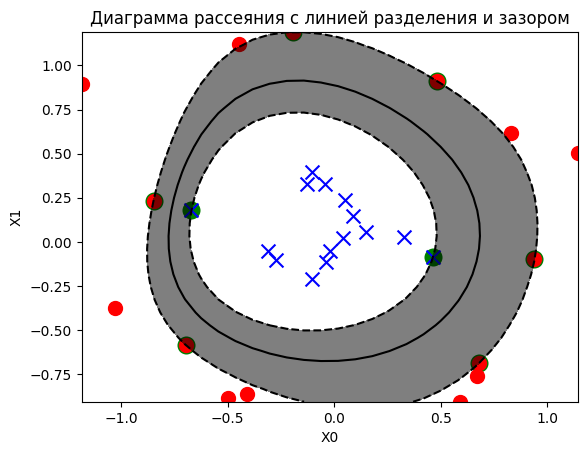

In [43]:
plot_decision_regions(X, y, svm_rbf)

In [45]:
accuracy_score(y, y_pred)
confusion_matrix(y, y_pred)

array([[7, 8],
       [8, 7]])

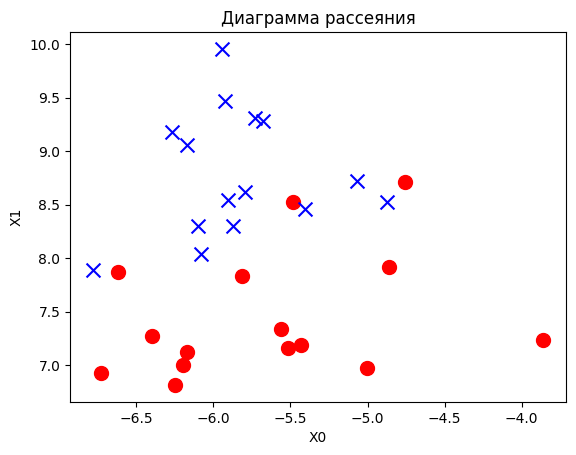

In [52]:
X, y = make_blobs(n_features=2, n_samples=30, centers=2, random_state=5, cluster_std=0.7)

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния")
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()

In [72]:
svm_poly = SVC(kernel='poly', degree=4, C=2).fit(X, y)

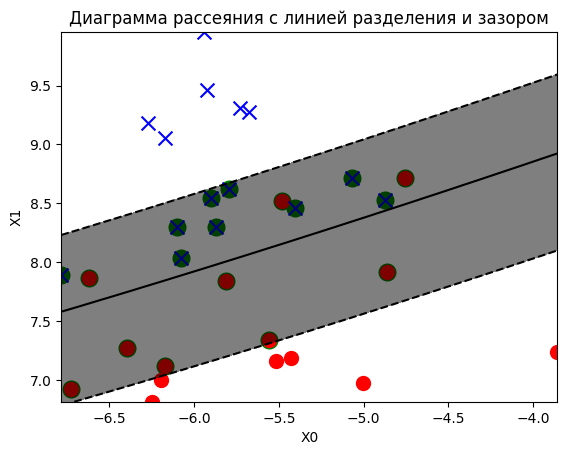

In [73]:
plot_decision_regions(X, y, svm_poly)

In [74]:
svm_poly.n_support_

array([9, 9], dtype=int32)

In [75]:
y_pred = svm_poly.predict(X)

In [76]:
accuracy_score(y, y_pred)
confusion_matrix(y, y_pred)

array([[12,  3],
       [ 0, 15]])

## Практическая работа

### 1. Эксперимент с различными значениями аргумента

In [78]:
X, y = make_blobs(n_features=2, n_samples=30, centers=2, random_state=5, cluster_std=0.4)

In [81]:
for C in [0.01, 0.1, 1, 10, 100, 1000]:
    svm = SVC(kernel='linear', C=C).fit(X, y)
    print(f"C = {C}: n_support = {svm.n_support_.sum()}, score = {svm.score(X, y):.4f}")


C = 0.01: n_support = 30, score = 1.0000
C = 0.1: n_support = 24, score = 0.9667
C = 1: n_support = 11, score = 0.9667
C = 10: n_support = 5, score = 1.0000
C = 100: n_support = 3, score = 1.0000
C = 1000: n_support = 3, score = 1.0000


Параметр C контролирует жесткость зазора. При малых C (0.01-0.1) модель допускает больше нарушений, использует много опорных векторов. При больших C (10-1000) зазор становится жестче, опорных векторов меньше. Значение C=10-100 оптимально для данного датасета.

### 2. Двигаем точку нового предсказания

In [82]:
X, y = make_blobs(n_features=2, n_samples=30, centers=2, random_state=5, cluster_std=0.4)
svm = SVC(kernel='linear', C=100).fit(X, y)

In [89]:
points = [[-6, 8], [-2, 6], [0, 5], [2, 3], [4, 1], [-11, 7]]

for point in points:
    pred = svm.predict([point])[0]
    decision = svm.decision_function([point])[0]
    print(f"Точка {point}: decision = {decision:.2f}, класс = {pred}")

Точка [-6, 8]: decision = -0.08, класс = 0
Точка [-2, 6]: decision = -22.37, класс = 0
Точка [0, 5]: decision = -33.52, класс = 0
Точка [2, 3]: decision = -50.81, класс = 0
Точка [4, 1]: decision = -68.10, класс = 0
Точка [-11, 7]: decision = 6.27, класс = 1


Предсказание определяется знаком decision_function. При попадании точки внутрь зазора (|decision| < 1) класс не меняется, но уверенность модели снижается. Чем дальше точка от границы, тем выше уверенность.

### 3. Анализ метода опорных векторов с другими видами ядра

In [90]:
X, y = make_circles(n_samples=30, random_state=5, factor=0.1, noise=0.2)

In [91]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']

for kernel in kernels:
    svm = SVC(kernel=kernel, C=100).fit(X, y)
    y_pred = svm.predict(X)
    print(f"{kernel}: accuracy = {accuracy_score(y, y_pred):.4f}, n_support = {svm.n_support_.sum()}")

linear: accuracy = 0.7000, n_support = 30
poly: accuracy = 0.7000, n_support = 29
rbf: accuracy = 1.0000, n_support = 8
sigmoid: accuracy = 0.5000, n_support = 18


RBF-ядро показало наилучший результат (accuracy=1.0), так как лучше всего адаптируется к нелинейной форме данных. Линейное и полиномиальное ядра не справились с разделением. Sigmoid-ядро показало худший результат (accuracy=0.5) — случайное угадывание. 

### 4. Эксперимент над значением C

In [92]:
X, y = make_blobs(n_features=2, n_samples=30, centers=2, random_state=5, cluster_std=0.7)

In [93]:
for C in [0.01, 0.1, 1, 10, 100, 1000]:
    svm = SVC(kernel='poly', degree=4, C=C).fit(X, y)
    print(f"C = {C}: accuracy = {svm.score(X, y):.4f}, n_support = {svm.n_support_.sum()}")

C = 0.01: accuracy = 0.7667, n_support = 30
C = 0.1: accuracy = 0.7667, n_support = 30
C = 1: accuracy = 0.8000, n_support = 21
C = 10: accuracy = 0.9000, n_support = 12
C = 100: accuracy = 0.9000, n_support = 10
C = 1000: accuracy = 0.8667, n_support = 9


C контролирует штраф за нарушение зазора. При малых C (0.01-0.1) модель мягкая, допускает ошибки, использует много опорных векторов. При увеличении C до 10-100 точность растет, опорных векторов становится меньше. При C=1000 точность снижается из-за переобучения. Оптимальное значение C=10-100.

### 5. Классификатор без ядра

In [95]:
from sklearn.svm import LinearSVC

In [96]:
X, y = make_blobs(n_features=2, n_samples=30, centers=2, random_state=5, cluster_std=0.7)

for C in [0.01, 0.1, 1, 10, 100]:
    svm = LinearSVC(C=C, max_iter=10000, dual='auto').fit(X, y)
    print(f"C = {C}: accuracy = {svm.score(X, y):.4f}")

C = 0.01: accuracy = 0.7000
C = 0.1: accuracy = 0.7667
C = 1: accuracy = 0.8000
C = 10: accuracy = 0.9000
C = 100: accuracy = 0.9000


LinearSVC показывает аналогичную зависимость от C: при малых значениях точность ниже, при увеличении C до 10-100 точность растет до максимума. В отличие от SVC, LinearSVC не имеет атрибутов support_vectors_ и n_support_, так как использует другую оптимизацию. Для линейно разделимых данных LinearSVC работает быстрее и эффективнее.

### 6. Датасет для классификации из 1000 точек и 5 атрибутов

In [98]:
from sklearn.datasets import make_classification

In [99]:
X, y = make_classification(n_samples=1000, n_features=5, n_classes=2, random_state=42)

In [100]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
C_values = [0.01, 0.1, 1, 10, 100]

for kernel in kernels:
    for C in C_values:
        svm = SVC(kernel=kernel, C=C).fit(X, y)
        print(f"{kernel}, C={C}: accuracy = {svm.score(X, y):.4f}")

linear, C=0.01: accuracy = 0.8630
linear, C=0.1: accuracy = 0.8630
linear, C=1: accuracy = 0.8630
linear, C=10: accuracy = 0.8630
linear, C=100: accuracy = 0.8630
poly, C=0.01: accuracy = 0.7720
poly, C=0.1: accuracy = 0.8490
poly, C=1: accuracy = 0.8720
poly, C=10: accuracy = 0.8660
poly, C=100: accuracy = 0.8670
rbf, C=0.01: accuracy = 0.8680
rbf, C=0.1: accuracy = 0.8710
rbf, C=1: accuracy = 0.8770
rbf, C=10: accuracy = 0.8820
rbf, C=100: accuracy = 0.9060
sigmoid, C=0.01: accuracy = 0.8630
sigmoid, C=0.1: accuracy = 0.8290
sigmoid, C=1: accuracy = 0.7770
sigmoid, C=10: accuracy = 0.7720
sigmoid, C=100: accuracy = 0.7720


Наилучший результат показало RBF-ядро с C=100 (accuracy=0.906). Линейное ядро стабильно, но уступает RBF. Полиномиальное ядро дает средние результаты. Sigmoid-ядро с увеличением C теряет качество. Рекомендуется использовать RBF-ядро с подбором C.

### 7. Модель с большим количеством точек

In [102]:
import time

In [103]:
for n_samples in [1000, 5000, 10000, 20000, 50000]:
    X, y = make_classification(n_samples=n_samples, n_features=5, n_classes=2, random_state=42)

    start = time.time()
    svm = SVC(kernel='rbf', C=100).fit(X, y)
    elapsed = time.time() - start
    
    print(f"{n_samples} точек: {elapsed:.2f} сек")

1000 точек: 0.02 сек
5000 точек: 0.15 сек
10000 точек: 0.47 сек
20000 точек: 1.61 сек
50000 точек: 5.01 сек


Время обучения растет нелинейно. До 10 000 точек обучение быстрое (до 0.5 сек). На 20 000 точек — уже 1.6 сек. На 50 000 точек — 5 сек. SVM показывает приемлемую скорость до 20 000-50 000 точек. Для миллионных выборок потребуется использование LinearSVC или приближенных методов.

### 8. Метод опорных векторов для множественной классификации

In [107]:
X, y = make_blobs(n_features=2, n_samples=150, centers=3, random_state=42, cluster_std=0.8)
svm = SVC(kernel='rbf', C=100).fit(X, y)

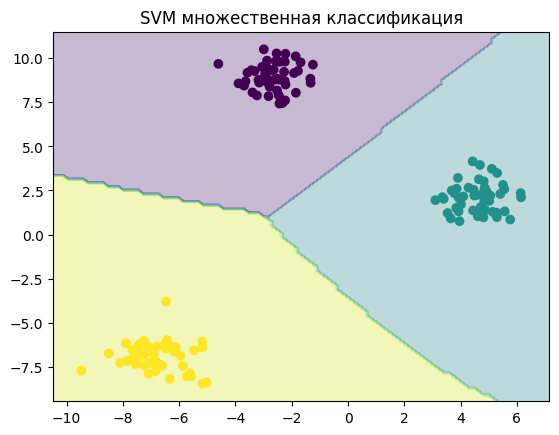

In [108]:
xx, yy = np.meshgrid(np.linspace(X[:, 0].min()-1, X[:, 0].max()+1, 100),
                     np.linspace(X[:, 1].min()-1, X[:, 1].max()+1, 100))
Z = svm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title('SVM множественная классификация')
plt.show()

### 9. Датасет классификации с методом опорных векторов

In [112]:
from sklearn.datasets import load_iris

In [113]:
data = load_iris()
svm = SVC(kernel='rbf', C=100).fit(data.data, data.target)
print(f"{data.data.shape[1]} признаков, {data.data.shape[0]} образцов: accuracy = {svm.score(data.data, data.target):.4f}")

4 признаков, 150 образцов: accuracy = 0.9867


### 10. Задача регрессии для другого датасета

In [119]:
from sklearn.datasets import fetch_california_housing
from sklearn.svm import SVR

In [116]:
housing = fetch_california_housing()

In [117]:
X, y = housing.data[:5000], housing.target[:5000]

In [120]:
svr = SVR(kernel='rbf', C=100).fit(X, y)
print(f"R2 = {svr.score(X, y):.4f}")

R2 = 0.4071


SVR на California housing показал низкий результат (R²=0.41). Это связано с тем, что метод опорных векторов чувствителен к масштабу признаков и плохо работает на больших выборках.